In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read csv 
node_df = pd.read_csv('data/NodeMetrics/NodeMetricsUpdate_0.csv')
node_df

,timestamp,nodeid,cpu_utilization,memory_utilization
0,33240000,NODE_23547,0.116474,0.462065
1,33240000,NODE_22287,0.345439,0.278756
2,33240000,NODE_21472,0.370310,0.223923
3,33240000,NODE_21294,0.144132,0.209197
4,33240000,NODE_20794,0.288578,0.147916
...,...,...,...,...
30587207,28500000,NODE_9418,0.104514,0.163205
30587208,28500000,NODE_960,0.217017,0.305994
30587209,28500000,NODE_9843,0.209468,0.137277
30587210,28560000,NODE_13195,0.323441,0.218299


In [3]:
ms_df = pd.read_csv('data/MSMetrics/MSMetricsUpdate_0.csv')
ms_df

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
0,300000,MS_68185,MS_68185_POD_91,NODE_20236,0.172378,0.662361
1,420000,MS_25215,MS_25215_POD_372,NODE_36528,0.085708,0.432862
2,720000,MS_31285,MS_31285_POD_916,NODE_23966,0.445229,0.572093
3,780000,MS_42019,MS_42019_POD_38,NODE_34880,0.091057,0.529339
4,900000,MS_9482,MS_9482_POD_332,NODE_45529,0.177660,0.642626
...,...,...,...,...,...,...
13987699,1380000,MS_22362,MS_22362_POD_69,NODE_40369,0.089460,0.428490
13987700,1440000,MS_56540,MS_56540_POD_24,NODE_7966,0.101820,0.468594
13987701,1500000,MS_65105,MS_65105_POD_77,NODE_8564,0.024190,0.193134
13987702,1560000,MS_61375,MS_61375_POD_74,NODE_17197,0.179640,0.595465


In [4]:
node_df.sort_values(by=['timestamp'], inplace=True)
ms_df.sort_values(by=['timestamp'], inplace=True)

In [5]:
(node_df["timestamp"].max() - node_df["timestamp"].min()) / (1000 * 60 * 60)

11.966666666666667

In [6]:
node_df["nodeid"].nunique()

43253

Observations about this cluster:

- Trace duration is 12 hours
- Not much node churn in the nodes of the cluster for the entire duration of the trace
- 43253 nodes in the cluster
- 28159 MSvces in this cluster (0.65nodes)
- 467613 MSinstances in this cluster (16.6 instances per ms)
- approximately 14 ms instances per node (10.8 pods per node)

for scalability exps:
- each node's capacity should be 1
- load on each worker should be drawn from an exp distribution with scale=0.7 (~10% of the times, the nodes will be overcapcaity)

In [110]:
28159 / 43253

0.6510299863593276

In [113]:
467613 / 28159

16.606164991654534

In [112]:
467613 / 43253

10.811111367997595

In [10]:
node_df

,timestamp,nodeid,cpu_utilization,memory_utilization
27437226,60000,NODE_43123,0.212331,0.261927
15426354,60000,NODE_42946,0.169482,0.260154
15426353,60000,NODE_43418,0.304042,0.381269
15426352,60000,NODE_43682,0.115481,0.195363
15426351,60000,NODE_44145,0.123785,0.199179
...,...,...,...,...
29333412,43140000,NODE_45257,0.166102,0.274498
29333413,43140000,NODE_45542,0.141797,0.224876
29333414,43140000,NODE_45550,0.045833,0.489857
29333404,43140000,NODE_42485,0.135694,0.136149


In [11]:
ms_df

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
1897293,0,MS_10845,MS_10845_POD_3,NODE_20712,0.093240,0.516560
6306961,0,MS_56120,MS_56120_POD_191,NODE_10480,0.169800,0.772035
11765565,0,MS_38052,MS_38052_POD_89,NODE_33773,0.030250,0.740018
11765564,0,MS_52269,MS_52269_POD_9,NODE_25766,0.518512,0.802101
6306941,0,MS_65234,MS_65234_POD_3,NODE_19469,0.037250,0.385601
...,...,...,...,...,...,...
10490540,1740000,MS_1947,MS_1947_POD_11,NODE_2537,0.344610,0.693202
4380397,1740000,MS_69117,MS_69117_POD_114,NODE_40326,0.060615,0.832229
2104494,1740000,MS_39923,MS_39923_POD_362,NODE_13658,0.222135,0.796066
11234990,1740000,MS_64207,MS_64207_POD_9,NODE_4859,0.107875,0.829227


<AxesSubplot: xlabel='nodeid', ylabel='Count'>

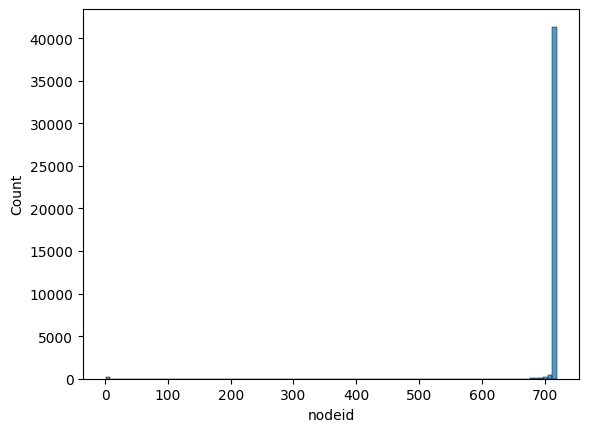

In [14]:
sns.histplot(node_df["nodeid"].value_counts(), bins=100)

In [102]:
# number of the microservices in one node:
a = ms_df.groupby(["timestamp", "nodeid"]).count().reset_index()["msinstanceid"].value_counts()
a.describe()

count       39.000000
mean     24209.512821
std      20277.641041
min         30.000000
25%       3022.500000
50%      20321.000000
75%      42026.000000
max      58073.000000
Name: msinstanceid, dtype: float64

In [107]:
tmp = ms_df.groupby(["timestamp", "nodeid"]).count().reset_index()["msinstanceid"]
tmp.describe()

count    944171.000000
mean         14.814799
std           7.187880
min           1.000000
25%          10.000000
50%          16.000000
75%          20.000000
max          40.000000
Name: msinstanceid, dtype: float64

<AxesSubplot: xlabel='msinstanceid', ylabel='Count'>

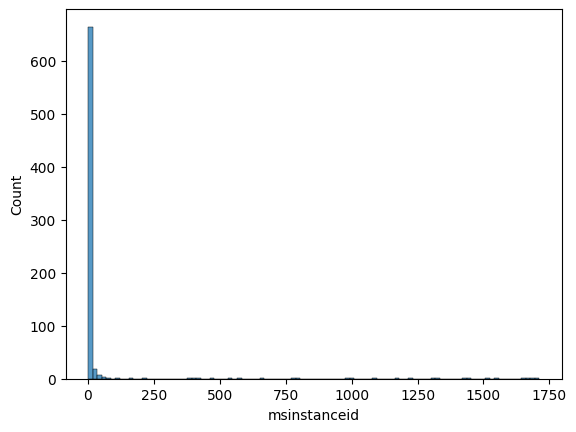

In [101]:
sns.histplot(a, bins=100)

In [31]:
# get the cdf of the number of msinstances for each msname
ms_df["msname"].value_counts().sort_values() # .reset_index(drop=True).plot(marker='o')

MS_69589         1
MS_40368         3
MS_73310         3
MS_46225         4
MS_48291         5
             ...  
MS_19988     49917
MS_66711     50997
MS_42222     55560
MS_43157     59880
MS_6945     230491
Name: msname, Length: 28159, dtype: int64

(0.0, 50000.0)

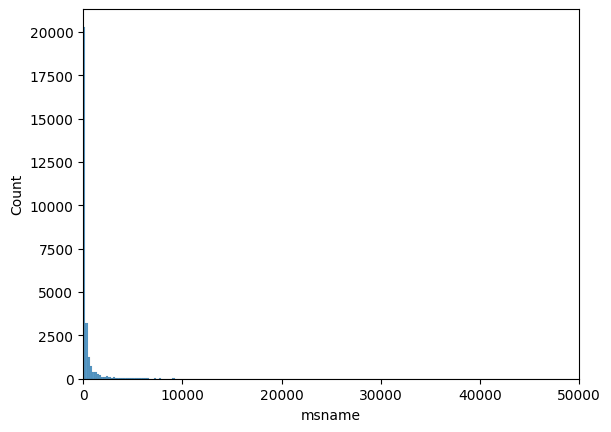

In [41]:
# have a histogram of the number of msinstances for each msname
sns.histplot(ms_df["msname"].value_counts(), bins=1000)
# plt.ylim(0, 100)
plt.xlim(0, 50000)

In [48]:
ms_df["msname"].value_counts().values

array([230491,  59880,  55560, ...,      3,      3,      1])

In [44]:
import numpy as np

In [89]:
def model_exponential_distribution(arr, scale=1.0):
    """
    Takes a NumPy array and generates an exponential distribution based on the input array.

    Parameters:
    arr (numpy.ndarray): Input array to model the exponential distribution.
    scale (float): The scale parameter (1/λ) for the exponential distribution (default is 1.0).

    Returns:
    numpy.ndarray: Array with values generated using the exponential distribution.
    """
    # Generate exponential values based on the shape of the input array
    exp_distribution = np.random.exponential(scale, size=arr.shape)
    
    return exp_distribution

# Example usage
input_array = ms_df["msname"].value_counts()
input_array = input_array[input_array < 10000].values
scale = 1 / np.mean(input_array)
output_array = model_exponential_distribution(input_array, scale=scale)
output_array *= 3

print("Input Array:", input_array)
print("Exponential Distribution:", output_array)

Input Array: [9960 9900 9900 ...    3    3    1]
Exponential Distribution: [0.00042505 0.00034416 0.02189741 ... 0.00085516 0.00510453 0.00050345]


In [130]:
arr = np.random.exponential(0.1, size=50000)
arr

array([0.11142509, 0.07566113, 0.23397948, ..., 0.17980606, 0.2691016 ,
       0.03193246])

<AxesSubplot: ylabel='Count'>

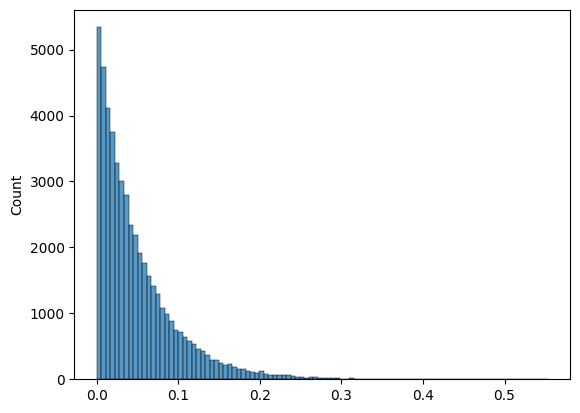

In [129]:
sns.histplot(arr, bins=100)

<AxesSubplot: xlabel='msname', ylabel='Count'>

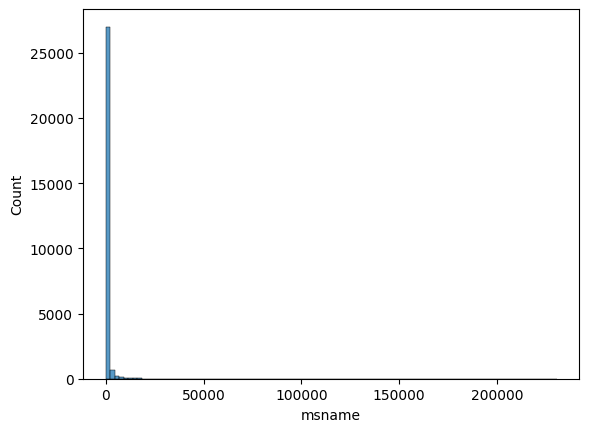

In [168]:
# have a histogram of the number of msinstances for each msname
sns.histplot(ms_df["msname"].value_counts(), bins=100)
# plt.ylim(0, 100)
# plt.xlim(0, 50000)

9.576%


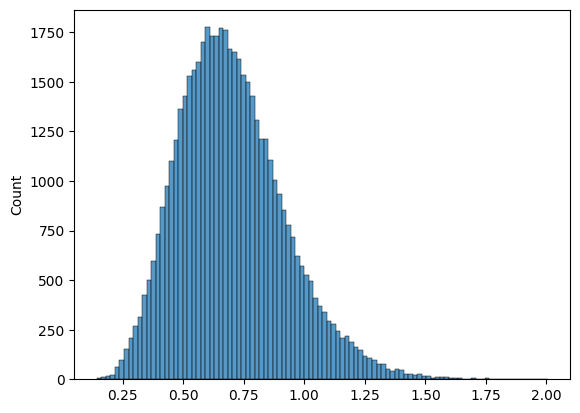

In [163]:
scale = 0.07
arrs = [np.random.exponential(scale, size=50000) for _ in range(10)]

sum_arr = np.sum(arrs, axis=0)
sns.histplot(sum_arr, bins=100)
# get the number of sum_arr > 1
print(f"{((sum_arr > 1).sum() / len(sum_arr)) * 100}%")

In [ ]:
scale = 0.07
arrs = [np.random.exponential(scale, size=50000) for _ in range(10)]

sum_arr = np.sum(arrs, axis=0)
sns.histplot(sum_arr, bins=100)
# get the number of sum_arr > 1
print(f"{((sum_arr > 1).sum() / len(sum_arr)) * 100}%")

In [175]:
v = ms_df["msname"].value_counts()

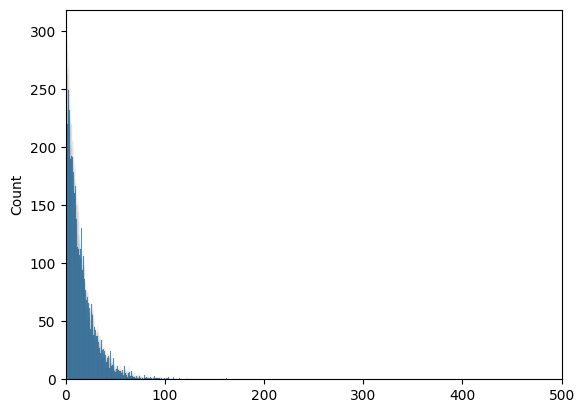

In [192]:
scale = 15
sns.histplot(np.random.exponential(scale, size=len(v)), bins=1000)
plt.xlim(0, 500)
plt.show()

In [198]:
2815*16

45040

In [197]:
np.sum(np.random.exponential(17, size=2815))

48971.788528497076

In [188]:
467613

467613

(0.0, 500.0)

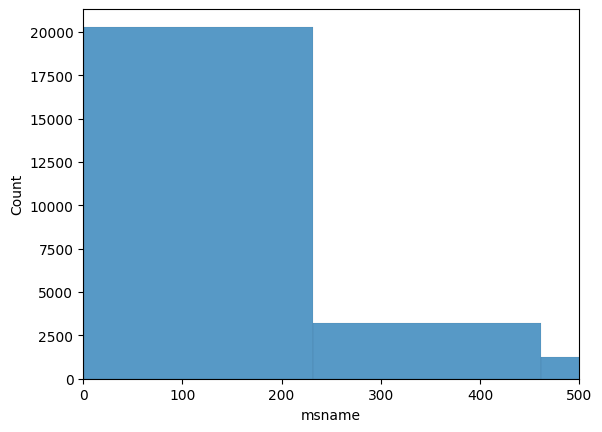

In [184]:
# have a histogram of the number of msinstances for each msname
sns.histplot(ms_df["msname"].value_counts(), bins=1000)
# plt.ylim(0, 100)
plt.xlim(0, 500)

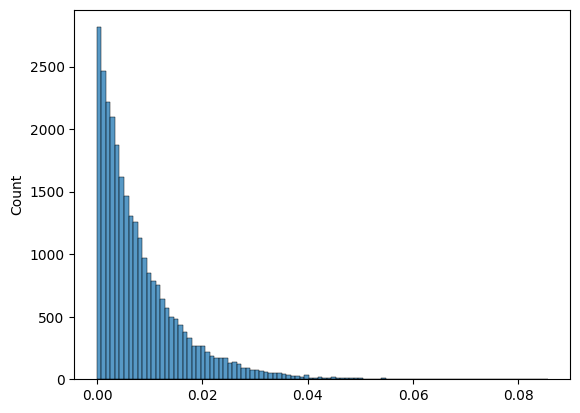

In [91]:
sns.histplot(output_array, bins=100)
# xlim = plt.xlim(0, 50000)
plt.show()

In [7]:
ms_df

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
1897293,0,MS_10845,MS_10845_POD_3,NODE_20712,0.093240,0.516560
6306961,0,MS_56120,MS_56120_POD_191,NODE_10480,0.169800,0.772035
11765565,0,MS_38052,MS_38052_POD_89,NODE_33773,0.030250,0.740018
11765564,0,MS_52269,MS_52269_POD_9,NODE_25766,0.518512,0.802101
6306941,0,MS_65234,MS_65234_POD_3,NODE_19469,0.037250,0.385601
...,...,...,...,...,...,...
10490540,1740000,MS_1947,MS_1947_POD_11,NODE_2537,0.344610,0.693202
4380397,1740000,MS_69117,MS_69117_POD_114,NODE_40326,0.060615,0.832229
2104494,1740000,MS_39923,MS_39923_POD_362,NODE_13658,0.222135,0.796066
11234990,1740000,MS_64207,MS_64207_POD_9,NODE_4859,0.107875,0.829227


In [7]:
len(node_df["nodeid"].unique())

43253

In [8]:
len(ms_df["msinstanceid"].unique())

467613

In [9]:
len(ms_df["msname"].unique())

28159

In [10]:
ms_df.loc[ms_df["msinstanceid"] == "MS_39923_POD_362"]

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
2096280,0,MS_39923,MS_39923_POD_362,NODE_13658,0.203304,0.796379
1710402,60000,MS_39923,MS_39923_POD_362,NODE_13658,0.202026,0.795256
2106914,120000,MS_39923,MS_39923_POD_362,NODE_13658,0.187423,0.795708
6293510,180000,MS_39923,MS_39923_POD_362,NODE_13658,0.217661,0.795965
2092185,240000,MS_39923,MS_39923_POD_362,NODE_13658,0.189341,0.796181
2100988,300000,MS_39923,MS_39923_POD_362,NODE_13658,0.186686,0.796189
6296433,360000,MS_39923,MS_39923_POD_362,NODE_13658,0.189243,0.795314
6292074,420000,MS_39923,MS_39923_POD_362,NODE_13658,0.200256,0.795721
2090932,480000,MS_39923,MS_39923_POD_362,NODE_13658,0.211220,0.795874
6298977,540000,MS_39923,MS_39923_POD_362,NODE_13658,0.197601,0.796179


In [11]:
ms_df_all = ms_df
ms_df = ms_df[["msname", "msinstanceid", "nodeid"]]
ms_df

,msname,msinstanceid,nodeid
1897293,MS_10845,MS_10845_POD_3,NODE_20712
6306961,MS_56120,MS_56120_POD_191,NODE_10480
11765565,MS_38052,MS_38052_POD_89,NODE_33773
11765564,MS_52269,MS_52269_POD_9,NODE_25766
6306941,MS_65234,MS_65234_POD_3,NODE_19469
...,...,...,...
10490540,MS_1947,MS_1947_POD_11,NODE_2537
4380397,MS_69117,MS_69117_POD_114,NODE_40326
2104494,MS_39923,MS_39923_POD_362,NODE_13658
11234990,MS_64207,MS_64207_POD_9,NODE_4859


In [12]:
ms_df = ms_df.drop_duplicates()

In [13]:
len(ms_df)

467615

In [14]:
ms_instance_series = ms_df["msinstanceid"]
ms_instance_series_unique = ms_df["msinstanceid"].unique()

In [15]:
len(ms_instance_series), len(ms_instance_series_unique)

(467615, 467613)

In [16]:
ms_instance_series.value_counts()

MS_6945_POD_9477     2
MS_6945_POD_9729     2
MS_10845_POD_3       1
MS_13752_POD_22      1
MS_37555_POD_1326    1
                    ..
MS_71672_POD_2       1
MS_49648_POD_42      1
MS_57157_POD_519     1
MS_68948_POD_2201    1
MS_37056_POD_26      1
Name: msinstanceid, Length: 467613, dtype: int64

In [17]:
ms_df_all[ms_df_all["msinstanceid"] == "MS_6945_POD_9729"]

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
5774618,0,MS_6945,MS_6945_POD_9729,NODE_21388,0.002250,0.124208
11140491,0,MS_6945,MS_6945_POD_9729,NODE_31027,0.016333,0.087728
1059029,60000,MS_6945,MS_6945_POD_9729,NODE_31027,0.017250,0.087762
5775083,60000,MS_6945,MS_6945_POD_9729,NODE_21388,0.000990,0.124208
5781841,120000,MS_6945,MS_6945_POD_9729,NODE_21388,0.001080,0.124208
11137905,120000,MS_6945,MS_6945_POD_9729,NODE_31027,0.016917,0.087968
5778505,180000,MS_6945,MS_6945_POD_9729,NODE_31027,0.018500,0.087703
5777891,180000,MS_6945,MS_6945_POD_9729,NODE_21388,0.001080,0.124208
5777293,240000,MS_6945,MS_6945_POD_9729,NODE_31027,0.016917,0.087975
5776483,240000,MS_6945,MS_6945_POD_9729,NODE_21388,0.000990,0.124208


In [25]:
ms_df.sort_values(by=['nodeid', 'msname'])

,msname,msinstanceid,nodeid
12378243,MS_11733,MS_11733_POD_27,NODE_10
4325704,MS_15097,MS_15097_POD_152,NODE_10
6307417,MS_2557,MS_2557_POD_52,NODE_10
3836418,MS_2562,MS_2562_POD_104,NODE_10
7255674,MS_27525,MS_27525_POD_4,NODE_10
...,...,...,...
7120781,MS_63360,MS_63360_POD_23,NODE_9999
5670399,MS_66711,MS_66711_POD_3461,NODE_9999
8245807,MS_69665,MS_69665_POD_560,NODE_9999
3504204,MS_69665,MS_69665_POD_541,NODE_9999


In [28]:
ms_df[ms_df["nodeid"] == "NODE_10"]

,msname,msinstanceid,nodeid
6307417,MS_2557,MS_2557_POD_52,NODE_10
8749457,MS_45705,MS_45705_POD_31,NODE_10
3415859,MS_72474,MS_72474_POD_72,NODE_10
11486735,MS_65402,MS_65402_POD_298,NODE_10
7255674,MS_27525,MS_27525_POD_4,NODE_10
693295,MS_9508,MS_9508_POD_30,NODE_10
12378243,MS_11733,MS_11733_POD_27,NODE_10
7884792,MS_49840,MS_49840_POD_364,NODE_10
3836418,MS_2562,MS_2562_POD_104,NODE_10
13759039,MS_65402,MS_65402_POD_282,NODE_10


In [48]:
def get_scenario1():
    ms_names = ms_df["msname"].unique()

    with open("data/scenario1.txt", "w") as f:
        for ms1 in ms_names:
            n1 = set(ms_df[ms_df["msname"] == ms1]["nodeid"].unique())
            for ms2 in ms_names:
                if ms1 != ms2:
                    n2 = set(ms_df[ms_df["msname"] == ms2]["nodeid"].unique())
                    
                    n12 = n1.intersection(n2)
                    if len(n12) > 0 and len(n12) < len(n1):
                        f.write(f"{ms1}\n{ms2}\n{n12}\n{n1}\n{n2}\n")

In [47]:
with open("data/scenario1.txt", "w") as f:
    f.write(f"{ms1}\n{ms2}\n{n12}\n{n1}\n{n2}\n")

In [49]:
get_scenario1()

KeyboardInterrupt: 

In [45]:
ms1, ms2, n12, n1, n2

('MS_10845',
 'MS_6298',
 {'NODE_20712', 'NODE_37722'},
 {'NODE_19678',
  'NODE_20712',
  'NODE_22484',
  'NODE_35520',
  'NODE_37722',
  'NODE_40080'},
 {'NODE_1000',
  'NODE_10004',
  'NODE_10196',
  'NODE_10215',
  'NODE_10218',
  'NODE_10281',
  'NODE_10297',
  'NODE_10310',
  'NODE_10344',
  'NODE_10369',
  'NODE_10397',
  'NODE_10423',
  'NODE_10437',
  'NODE_10455',
  'NODE_10472',
  'NODE_10477',
  'NODE_10549',
  'NODE_10575',
  'NODE_10598',
  'NODE_10822',
  'NODE_10867',
  'NODE_11047',
  'NODE_11063',
  'NODE_11121',
  'NODE_11145',
  'NODE_11173',
  'NODE_1119',
  'NODE_11264',
  'NODE_11334',
  'NODE_11338',
  'NODE_11469',
  'NODE_11540',
  'NODE_11575',
  'NODE_11733',
  'NODE_11751',
  'NODE_11752',
  'NODE_11817',
  'NODE_11884',
  'NODE_120',
  'NODE_12059',
  'NODE_12196',
  'NODE_12201',
  'NODE_12210',
  'NODE_12257',
  'NODE_12267',
  'NODE_1249',
  'NODE_12524',
  'NODE_12598',
  'NODE_12663',
  'NODE_12812',
  'NODE_12905',
  'NODE_13193',
  'NODE_1320',
  'NO

In [ ]:
MS_48931
MS_68431
{'NODE_7314', 'NODE_28896', 'NODE_24886', 'NODE_14289'}
{'NODE_18379', 'NODE_41900', 'NODE_1345', 'NODE_15354', 'NODE_11471', 'NODE_40915', 'NODE_36442', 'NODE_38244', 'NODE_216', 'NODE_35079', 'NODE_41026', 'NODE_39256', 'NODE_35384', 'NODE_37126', 'NODE_10538', 'NODE_24670', 'NODE_6650', 'NODE_46842', 'NODE_2328', 'NODE_2264', 'NODE_16614', 'NODE_8390', 'NODE_40250', 'NODE_11832', 'NODE_27609', 'NODE_38579', 'NODE_36936', 'NODE_21930', 'NODE_38425', 'NODE_6874', 'NODE_11894', 'NODE_47168', 'NODE_803', 'NODE_37486', 'NODE_7205', 'NODE_25495', 'NODE_7008', 'NODE_13074', 'NODE_4485', 'NODE_19846', 'NODE_11526', 'NODE_29213', 'NODE_24005', 'NODE_7165', 'NODE_29127', 'NODE_9775', 'NODE_16058', 'NODE_25445', 'NODE_21235', 'NODE_36317', 'NODE_16452', 'NODE_43327', 'NODE_29234', 'NODE_24127', 'NODE_14716', 'NODE_8088', 'NODE_38025', 'NODE_35418', 'NODE_22232', 'NODE_26355', 'NODE_42337', 'NODE_35488', 'NODE_37333', 'NODE_41706', 'NODE_39963', 'NODE_46381', 'NODE_8331', 'NODE_11145', 'NODE_30530', 'NODE_9082', 'NODE_37250', 'NODE_13435', 'NODE_28651', 'NODE_10714', 'NODE_1286', 'NODE_7880', 'NODE_7617', 'NODE_7153', 'NODE_36055', 'NODE_41504', 'NODE_37413', 'NODE_20678', 'NODE_32290', 'NODE_30241', 'NODE_6721', 'NODE_30493', 'NODE_5616', 'NODE_21254', 'NODE_30987', 'NODE_36519', 'NODE_34338', 'NODE_38812', 'NODE_17153', 'NODE_12356', 'NODE_35056', 'NODE_6587', 'NODE_44780', 'NODE_43675', 'NODE_37035', 'NODE_41326', 'NODE_32477', 'NODE_16064', 'NODE_18766', 'NODE_27691', 'NODE_33575', 'NODE_20290', 'NODE_40074', 'NODE_36228', 'NODE_31303', 'NODE_19384', 'NODE_37328', 'NODE_22041', 'NODE_24268', 'NODE_32317', 'NODE_30548', 'NODE_33958', 'NODE_4233', 'NODE_3186', 'NODE_23353', 'NODE_14261', 'NODE_20614', 'NODE_42574', 'NODE_37282', 'NODE_29570', 'NODE_15513', 'NODE_28202', 'NODE_41398', 'NODE_35780', 'NODE_17325', 'NODE_26847', 'NODE_41034', 'NODE_39546', 'NODE_30117', 'NODE_14411', 'NODE_38321', 'NODE_34627', 'NODE_2247', 'NODE_1461', 'NODE_11629', 'NODE_43139', 'NODE_13747', 'NODE_24835', 'NODE_38243', 'NODE_6555', 'NODE_16573', 'NODE_10857', 'NODE_8627', 'NODE_24676', 'NODE_32391', 'NODE_15666', 'NODE_23930', 'NODE_29501', 'NODE_13982', 'NODE_5207', 'NODE_37277', 'NODE_46599', 'NODE_21129', 'NODE_34448', 'NODE_23202', 'NODE_5209', 'NODE_33790', 'NODE_30976', 'NODE_46887', 'NODE_17388', 'NODE_25551', 'NODE_32823', 'NODE_31124', 'NODE_10715', 'NODE_8013', 'NODE_4149', 'NODE_19461', 'NODE_22237', 'NODE_28853', 'NODE_5285', 'NODE_35697', 'NODE_45473', 'NODE_43492', 'NODE_1741', 'NODE_36299', 'NODE_23894', 'NODE_2317', 'NODE_10811', 'NODE_29514', 'NODE_7002', 'NODE_41078', 'NODE_7012', 'NODE_18928', 'NODE_44568', 'NODE_16939', 'NODE_40746', 'NODE_9266', 'NODE_16548', 'NODE_45888', 'NODE_4755', 'NODE_34449', 'NODE_40319', 'NODE_29642', 'NODE_9699', 'NODE_17170', 'NODE_33598', 'NODE_35011', 'NODE_36705', 'NODE_14289', 'NODE_44051', 'NODE_19014', 'NODE_3022', 'NODE_69', 'NODE_9769', 'NODE_29734', 'NODE_7304', 'NODE_1705', 'NODE_40279', 'NODE_28953', 'NODE_7631', 'NODE_7314', 'NODE_30226', 'NODE_44416', 'NODE_32521', 'NODE_29544', 'NODE_18616', 'NODE_14424', 'NODE_25311', 'NODE_32099', 'NODE_11687', 'NODE_13881', 'NODE_42966', 'NODE_21339', 'NODE_4281', 'NODE_12041', 'NODE_1141', 'NODE_20204', 'NODE_32012', 'NODE_23435', 'NODE_2950', 'NODE_42947', 'NODE_13061', 'NODE_44793', 'NODE_18086', 'NODE_46130', 'NODE_34231', 'NODE_37124', 'NODE_26306', 'NODE_37494', 'NODE_34583', 'NODE_17180', 'NODE_6571', 'NODE_45288', 'NODE_46785', 'NODE_35023', 'NODE_3277', 'NODE_35351', 'NODE_44747', 'NODE_39991', 'NODE_9874', 'NODE_41462', 'NODE_20583', 'NODE_20739', 'NODE_20208', 'NODE_9940', 'NODE_25919', 'NODE_46352', 'NODE_46829', 'NODE_39624', 'NODE_22088', 'NODE_35069', 'NODE_9112', 'NODE_14714', 'NODE_37691', 'NODE_33407', 'NODE_45168', 'NODE_30925', 'NODE_27421', 'NODE_45513', 'NODE_5968', 'NODE_6324', 'NODE_44848', 'NODE_23015', 'NODE_7209', 'NODE_19501', 'NODE_45987', 'NODE_27817', 'NODE_14802', 'NODE_28871', 'NODE_37210', 'NODE_35266', 'NODE_13591', 'NODE_8020', 'NODE_28602', 'NODE_4661', 'NODE_5849', 'NODE_37678', 'NODE_23116', 'NODE_3195', 'NODE_11', 'NODE_3841', 'NODE_15648', 'NODE_35494', 'NODE_9739', 'NODE_11746', 'NODE_43164', 'NODE_3585', 'NODE_5747', 'NODE_7358', 'NODE_46171', 'NODE_19575', 'NODE_16302', 'NODE_16502', 'NODE_34136', 'NODE_12585', 'NODE_29810', 'NODE_39430', 'NODE_9688', 'NODE_1290', 'NODE_9969', 'NODE_5198', 'NODE_8573', 'NODE_22572', 'NODE_2189', 'NODE_46966', 'NODE_40096', 'NODE_10325', 'NODE_14909', 'NODE_30350', 'NODE_43259', 'NODE_17837', 'NODE_41913', 'NODE_41555', 'NODE_11107', 'NODE_30016', 'NODE_8980', 'NODE_8044', 'NODE_17978', 'NODE_17095', 'NODE_30451', 'NODE_41442', 'NODE_7942', 'NODE_25190', 'NODE_17248', 'NODE_12083', 'NODE_18161', 'NODE_15579', 'NODE_292', 'NODE_22520', 'NODE_2779', 'NODE_26796', 'NODE_36777', 'NODE_29639', 'NODE_4368', 'NODE_1929', 'NODE_36341', 'NODE_5633', 'NODE_42026', 'NODE_3619', 'NODE_26072', 'NODE_37225', 'NODE_42721', 'NODE_27584', 'NODE_43230', 'NODE_19105', 'NODE_46550', 'NODE_41790', 'NODE_8557', 'NODE_15363', 'NODE_29103', 'NODE_24993', 'NODE_21772', 'NODE_34371', 'NODE_2467', 'NODE_20942', 'NODE_41444', 'NODE_38312', 'NODE_27491', 'NODE_43229', 'NODE_21024', 'NODE_10642', 'NODE_10727', 'NODE_35827', 'NODE_44490', 'NODE_18491', 'NODE_34617', 'NODE_29129', 'NODE_36282', 'NODE_34115', 'NODE_8241', 'NODE_19419', 'NODE_9515', 'NODE_40323', 'NODE_24858', 'NODE_1853', 'NODE_30837', 'NODE_2738', 'NODE_7116', 'NODE_26551', 'NODE_27588', 'NODE_16364', 'NODE_25105', 'NODE_32814', 'NODE_20245', 'NODE_46815', 'NODE_22313', 'NODE_5627', 'NODE_33514', 'NODE_9573', 'NODE_33500', 'NODE_41663', 'NODE_4348', 'NODE_31302', 'NODE_39952', 'NODE_42387', 'NODE_32204', 'NODE_8217', 'NODE_1283', 'NODE_27297', 'NODE_21507', 'NODE_36841', 'NODE_9630', 'NODE_21539', 'NODE_33927', 'NODE_23337', 'NODE_7903', 'NODE_36075', 'NODE_11442', 'NODE_36497', 'NODE_42551', 'NODE_10296', 'NODE_33742', 'NODE_4566', 'NODE_28056', 'NODE_483', 'NODE_23572', 'NODE_12571', 'NODE_22165', 'NODE_47240', 'NODE_40913', 'NODE_47029', 'NODE_31268', 'NODE_45975', 'NODE_19549', 'NODE_39849', 'NODE_18', 'NODE_43727', 'NODE_10556', 'NODE_28121', 'NODE_29630', 'NODE_4111', 'NODE_7117', 'NODE_6033', 'NODE_16532', 'NODE_35974', 'NODE_4429', 'NODE_2632', 'NODE_46464', 'NODE_4417', 'NODE_27231', 'NODE_20450', 'NODE_14201', 'NODE_46527', 'NODE_13963', 'NODE_18922', 'NODE_20166', 'NODE_24138', 'NODE_22283', 'NODE_43921', 'NODE_1405', 'NODE_26869', 'NODE_26989', 'NODE_3031', 'NODE_12276', 'NODE_6136', 'NODE_28113', 'NODE_26331', 'NODE_16274', 'NODE_23899', 'NODE_17607', 'NODE_19589', 'NODE_25498', 'NODE_2577', 'NODE_22290', 'NODE_36077', 'NODE_12486', 'NODE_33336', 'NODE_16075', 'NODE_20706', 'NODE_12168', 'NODE_9256', 'NODE_2663', 'NODE_46910', 'NODE_23647', 'NODE_3803', 'NODE_2550', 'NODE_26041', 'NODE_32429', 'NODE_10202', 'NODE_23205', 'NODE_29355', 'NODE_39789', 'NODE_28520', 'NODE_35388', 'NODE_27010', 'NODE_13460', 'NODE_44786', 'NODE_39189', 'NODE_19679', 'NODE_45149', 'NODE_26444', 'NODE_20862', 'NODE_28829', 'NODE_11191', 'NODE_20258', 'NODE_10626', 'NODE_18193', 'NODE_35788', 'NODE_9359', 'NODE_44388', 'NODE_30597', 'NODE_39085', 'NODE_41456', 'NODE_46847', 'NODE_31765', 'NODE_4244', 'NODE_25162', 'NODE_37816', 'NODE_19341', 'NODE_42352', 'NODE_32753', 'NODE_13321', 'NODE_9593', 'NODE_14567', 'NODE_2561', 'NODE_4076', 'NODE_18829', 'NODE_28994', 'NODE_36969', 'NODE_32182', 'NODE_25106', 'NODE_12592', 'NODE_13393', 'NODE_5900', 'NODE_45379', 'NODE_17271', 'NODE_45153', 'NODE_34635', 'NODE_2075', 'NODE_8901', 'NODE_15864', 'NODE_36031', 'NODE_10769', 'NODE_26579', 'NODE_35366', 'NODE_30460', 'NODE_28119', 'NODE_31471', 'NODE_38011', 'NODE_43526', 'NODE_38449', 'NODE_22486', 'NODE_13452', 'NODE_8338', 'NODE_10518', 'NODE_30702', 'NODE_13463', 'NODE_21711', 'NODE_11628', 'NODE_17543', 'NODE_7308', 'NODE_30003', 'NODE_7214', 'NODE_26696', 'NODE_46977', 'NODE_46993', 'NODE_45986', 'NODE_35185', 'NODE_28502', 'NODE_17518', 'NODE_40318', 'NODE_12373', 'NODE_14556', 'NODE_3583', 'NODE_31927', 'NODE_26477', 'NODE_32478', 'NODE_27197', 'NODE_45497', 'NODE_9550', 'NODE_186', 'NODE_32644', 'NODE_43926', 'NODE_2015', 'NODE_7904', 'NODE_43695', 'NODE_32304', 'NODE_46777', 'NODE_26063', 'NODE_24512', 'NODE_25130', 'NODE_32919', 'NODE_14364', 'NODE_35961', 'NODE_13078', 'NODE_18349', 'NODE_14301', 'NODE_14135', 'NODE_19472', 'NODE_24051', 'NODE_6543', 'NODE_20177', 'NODE_18139', 'NODE_33728', 'NODE_36779', 'NODE_23752', 'NODE_28341', 'NODE_5171', 'NODE_1943', 'NODE_22175', 'NODE_8438', 'NODE_21529', 'NODE_2608', 'NODE_15821', 'NODE_34946', 'NODE_12332', 'NODE_18300', 'NODE_22946', 'NODE_24094', 'NODE_5638', 'NODE_12649', 'NODE_31408', 'NODE_16327', 'NODE_32680', 'NODE_24886', 'NODE_20766', 'NODE_21909', 'NODE_26913', 'NODE_23798', 'NODE_28656', 'NODE_11174', 'NODE_20567', 'NODE_42429', 'NODE_36886', 'NODE_29424', 'NODE_19654', 'NODE_13193', 'NODE_19270', 'NODE_40443', 'NODE_33103', 'NODE_47056', 'NODE_9695', 'NODE_23778', 'NODE_39718', 'NODE_12303', 'NODE_555', 'NODE_44817', 'NODE_1104', 'NODE_34086', 'NODE_40271', 'NODE_28274', 'NODE_38331', 'NODE_36946', 'NODE_15616', 'NODE_28627', 'NODE_7434', 'NODE_15923', 'NODE_2505', 'NODE_24059', 'NODE_42391', 'NODE_41846', 'NODE_28896', 'NODE_43725', 'NODE_11801', 'NODE_34789', 'NODE_41834', 'NODE_36439', 'NODE_21738', 'NODE_23952', 'NODE_22608', 'NODE_41540', 'NODE_13879', 'NODE_3033', 'NODE_25158', 'NODE_41142', 'NODE_28258', 'NODE_20378', 'NODE_36488', 'NODE_40017', 'NODE_43614', 'NODE_29815', 'NODE_23122', 'NODE_30712', 'NODE_43904', 'NODE_33333', 'NODE_12287', 'NODE_45108', 'NODE_16354', 'NODE_26516', 'NODE_40613', 'NODE_40971', 'NODE_27318', 'NODE_21278', 'NODE_29885', 'NODE_39543', 'NODE_13303', 'NODE_39389', 'NODE_27904', 'NODE_8318', 'NODE_6155', 'NODE_11179', 'NODE_12499', 'NODE_16881', 'NODE_14108', 'NODE_14137', 'NODE_17844', 'NODE_33706', 'NODE_34364', 'NODE_40492', 'NODE_31258', 'NODE_37765', 'NODE_6409', 'NODE_44698', 'NODE_42939', 'NODE_9634', 'NODE_28328', 'NODE_43118', 'NODE_38563', 'NODE_36246', 'NODE_40794', 'NODE_36815', 'NODE_27579', 'NODE_46843', 'NODE_16375', 'NODE_19225', 'NODE_47304', 'NODE_10930', 'NODE_40114', 'NODE_41536', 'NODE_16673', 'NODE_6864', 'NODE_11784', 'NODE_10496', 'NODE_40119', 'NODE_29397', 'NODE_44034', 'NODE_2745', 'NODE_41825', 'NODE_8206', 'NODE_21180', 'NODE_31523', 'NODE_25179', 'NODE_39820', 'NODE_21918', 'NODE_16814', 'NODE_4405', 'NODE_20745', 'NODE_19527', 'NODE_43716', 'NODE_21336', 'NODE_10037', 'NODE_4179', 'NODE_4274', 'NODE_11847', 'NODE_7916', 'NODE_23555', 'NODE_4584', 'NODE_45764', 'NODE_11356', 'NODE_43179', 'NODE_11533', 'NODE_11857', 'NODE_35848', 'NODE_8287', 'NODE_46456', 'NODE_653', 'NODE_20254', 'NODE_29890', 'NODE_26290', 'NODE_4364', 'NODE_12797', 'NODE_22128', 'NODE_24076', 'NODE_13519', 'NODE_42650', 'NODE_7726', 'NODE_2135', 'NODE_7148', 'NODE_30728', 'NODE_35402', 'NODE_27164', 'NODE_30958', 'NODE_2261', 'NODE_18712', 'NODE_44322', 'NODE_18985', 'NODE_30906', 'NODE_27388', 'NODE_7694', 'NODE_25700', 'NODE_42724', 'NODE_2054', 'NODE_8233', 'NODE_30741', 'NODE_41468', 'NODE_1208', 'NODE_38592', 'NODE_28641', 'NODE_6835', 'NODE_47163', 'NODE_44489', 'NODE_27482', 'NODE_42786', 'NODE_17151', 'NODE_33680', 'NODE_27873', 'NODE_33569', 'NODE_36334', 'NODE_21432', 'NODE_46181', 'NODE_28714', 'NODE_23313', 'NODE_22583'}
{'NODE_12731', 'NODE_23726', 'NODE_15628', 'NODE_31690', 'NODE_11731', 'NODE_15670', 'NODE_28896', 'NODE_2674', 'NODE_8661', 'NODE_31285', 'NODE_2185', 'NODE_31740', 'NODE_43014', 'NODE_25550', 'NODE_32466', 'NODE_26593', 'NODE_24886', 'NODE_14289', 'NODE_36977', 'NODE_7314', 'NODE_29959', 'NODE_40968', 'NODE_35284', 'NODE_30892', 'NODE_33288', 'NODE_31083'}


In [53]:
{'NODE_7314', 'NODE_28896', 'NODE_24886', 'NODE_14289'}
ms_df[ms_df["nodeid"] == "NODE_14289"]

,msname,msinstanceid,nodeid
12955546,MS_68948,MS_68948_POD_537,NODE_14289
1972664,MS_35921,MS_35921_POD_57,NODE_14289
2125631,MS_42921,MS_42921_POD_195,NODE_14289
8823256,MS_3843,MS_3843_POD_229,NODE_14289
2067670,MS_42926,MS_42926_POD_2,NODE_14289
13236995,MS_63505,MS_63505_POD_16,NODE_14289
13210515,MS_68431,MS_68431_POD_7,NODE_14289
6067518,MS_16601,MS_16601_POD_869,NODE_14289
12260639,MS_1769,MS_1769_POD_2,NODE_14289
780198,MS_48931,MS_48931_POD_580,NODE_14289


In [ ]:
MS_10845
MS_37281
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722', 'NODE_34840', 'NODE_4688'}

In [ ]:
MS_10845
MS_16391
{'NODE_22484'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_22484'}

In [ ]:
MS_10845
MS_61997
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722'}

In [ ]:
MS_10845
MS_16926
{'NODE_37722'}
{'NODE_37722', 'NODE_20712', 'NODE_35520', 'NODE_40080', 'NODE_22484', 'NODE_19678'}
{'NODE_37722', 'NODE_23149'}

In [54]:
ms_df[ms_df["nodeid"] == "NODE_37722"]

,msname,msinstanceid,nodeid
6147380,MS_16399,MS_16399_POD_46,NODE_37722
12859610,MS_66054,MS_66054_POD_2,NODE_37722
8814066,MS_16926,MS_16926_POD_0,NODE_37722
9404544,MS_6298,MS_6298_POD_131,NODE_37722
5838207,MS_32145,MS_32145_POD_50,NODE_37722
7398598,MS_10845,MS_10845_POD_4,NODE_37722
2694857,MS_4339,MS_4339_POD_180,NODE_37722
12131401,MS_37281,MS_37281_POD_1,NODE_37722
12151031,MS_73304,MS_73304_POD_93,NODE_37722
7692500,MS_5771,MS_5771_POD_6,NODE_37722


In [ ]:
MS_19349
MS_3519
{'NODE_21694', 'NODE_30524', 'NODE_36756', 'NODE_37164', 'NODE_45589', 'NODE_37217'}
{'NODE_11456', 'NODE_6672', 'NODE_15354', 'NODE_42638', 'NODE_42745', 'NODE_4632', 'NODE_38825', 'NODE_15700', 'NODE_20620', 'NODE_10771', 'NODE_12639', 'NODE_1955', 'NODE_36350', 'NODE_26186', 'NODE_1105', 'NODE_7275', 'NODE_21893', 'NODE_21930', 'NODE_45927', 'NODE_34341', 'NODE_10944', 'NODE_2765', 'NODE_19999', 'NODE_29360', 'NODE_1688', 'NODE_46554', 'NODE_22204', 'NODE_43970', 'NODE_12764', 'NODE_42337', 'NODE_21091', 'NODE_33378', 'NODE_3563', 'NODE_9082', 'NODE_35409', 'NODE_40814', 'NODE_30462', 'NODE_16073', 'NODE_2509', 'NODE_15078', 'NODE_44048', 'NODE_4795', 'NODE_44599', 'NODE_307', 'NODE_38812', 'NODE_47058', 'NODE_45589', 'NODE_40656', 'NODE_37568', 'NODE_43028', 'NODE_19974', 'NODE_43603', 'NODE_23598', 'NODE_46778', 'NODE_34706', 'NODE_13820', 'NODE_14836', 'NODE_3426', 'NODE_5819', 'NODE_32317', 'NODE_34810', 'NODE_9076', 'NODE_47073', 'NODE_45083', 'NODE_44797', 'NODE_10179', 'NODE_25956', 'NODE_17531', 'NODE_35780', 'NODE_24204', 'NODE_25940', 'NODE_12428', 'NODE_20381', 'NODE_28116', 'NODE_44732', 'NODE_6873', 'NODE_7227', 'NODE_10486', 'NODE_22259', 'NODE_30672', 'NODE_20693', 'NODE_32110', 'NODE_38675', 'NODE_809', 'NODE_30279', 'NODE_1580', 'NODE_27324', 'NODE_3120', 'NODE_42598', 'NODE_13701', 'NODE_28499', 'NODE_30524', 'NODE_12063', 'NODE_33804', 'NODE_24401', 'NODE_23304', 'NODE_15774', 'NODE_13488', 'NODE_40212', 'NODE_21936', 'NODE_2187', 'NODE_34825', 'NODE_13836', 'NODE_30352', 'NODE_19838', 'NODE_3845', 'NODE_30093', 'NODE_41789', 'NODE_11261', 'NODE_23371', 'NODE_38848', 'NODE_22702', 'NODE_4590', 'NODE_38326', 'NODE_1974', 'NODE_41850', 'NODE_15433', 'NODE_8063', 'NODE_30035', 'NODE_16704', 'NODE_8156', 'NODE_9169', 'NODE_33377', 'NODE_39881', 'NODE_8067', 'NODE_19120', 'NODE_39120', 'NODE_26823', 'NODE_1823', 'NODE_29082', 'NODE_6998', 'NODE_43527', 'NODE_5741', 'NODE_10874', 'NODE_31386', 'NODE_22343', 'NODE_7132', 'NODE_30758', 'NODE_37307', 'NODE_34162', 'NODE_4281', 'NODE_28283', 'NODE_19772', 'NODE_35174', 'NODE_21491', 'NODE_10989', 'NODE_42879', 'NODE_25685', 'NODE_44674', 'NODE_26306', 'NODE_35001', 'NODE_31101', 'NODE_42739', 'NODE_16139', 'NODE_19615', 'NODE_43192', 'NODE_43608', 'NODE_29907', 'NODE_9112', 'NODE_45706', 'NODE_21290', 'NODE_14714', 'NODE_15195', 'NODE_31744', 'NODE_24207', 'NODE_37406', 'NODE_24137', 'NODE_36940', 'NODE_27835', 'NODE_4083', 'NODE_15049', 'NODE_5251', 'NODE_15341', 'NODE_22796', 'NODE_14924', 'NODE_38468', 'NODE_32734', 'NODE_30668', 'NODE_44321', 'NODE_5977', 'NODE_33788', 'NODE_37217', 'NODE_40456', 'NODE_9945', 'NODE_36329', 'NODE_33193', 'NODE_33977', 'NODE_41637', 'NODE_35941', 'NODE_42329', 'NODE_36310', 'NODE_7499', 'NODE_45553', 'NODE_43521', 'NODE_2228', 'NODE_34835', 'NODE_24739', 'NODE_36160', 'NODE_23697', 'NODE_11912', 'NODE_5895', 'NODE_39927', 'NODE_12012', 'NODE_43066', 'NODE_20599', 'NODE_17053', 'NODE_14117', 'NODE_31559', 'NODE_36593', 'NODE_39465', 'NODE_6642', 'NODE_45797', 'NODE_7714', 'NODE_2508', 'NODE_563', 'NODE_13674', 'NODE_14677', 'NODE_34802', 'NODE_23859', 'NODE_25269', 'NODE_33985', 'NODE_17701', 'NODE_26175', 'NODE_18161', 'NODE_11557', 'NODE_44323', 'NODE_29116', 'NODE_442', 'NODE_12824', 'NODE_42026', 'NODE_17675', 'NODE_36807', 'NODE_27584', 'NODE_12962', 'NODE_13998', 'NODE_29264', 'NODE_37062', 'NODE_47068', 'NODE_36917', 'NODE_43911', 'NODE_24993', 'NODE_43110', 'NODE_29376', 'NODE_36381', 'NODE_39433', 'NODE_30922', 'NODE_31519', 'NODE_33399', 'NODE_5041', 'NODE_7154', 'NODE_47072', 'NODE_26479', 'NODE_15047', 'NODE_12061', 'NODE_11729', 'NODE_31682', 'NODE_29080', 'NODE_43865', 'NODE_20950', 'NODE_42141', 'NODE_10150', 'NODE_23124', 'NODE_45881', 'NODE_31310', 'NODE_30802', 'NODE_45243', 'NODE_38202', 'NODE_37008', 'NODE_20611', 'NODE_16797', 'NODE_5481', 'NODE_3920', 'NODE_30160', 'NODE_34896', 'NODE_33500', 'NODE_7562', 'NODE_46899', 'NODE_13265', 'NODE_39982', 'NODE_15448', 'NODE_22134', 'NODE_21535', 'NODE_4974', 'NODE_6160', 'NODE_41565', 'NODE_12956', 'NODE_45506', 'NODE_36497', 'NODE_41474', 'NODE_39019', 'NODE_28445', 'NODE_46495', 'NODE_42906', 'NODE_9674', 'NODE_10509', 'NODE_20799', 'NODE_37081', 'NODE_19272', 'NODE_18863', 'NODE_31543', 'NODE_16872', 'NODE_20397', 'NODE_32289', 'NODE_11120', 'NODE_11030', 'NODE_28040', 'NODE_38211', 'NODE_21579', 'NODE_451', 'NODE_11975', 'NODE_13058', 'NODE_35701', 'NODE_42086', 'NODE_4964', 'NODE_29759', 'NODE_20845', 'NODE_29865', 'NODE_28045', 'NODE_36715', 'NODE_25686', 'NODE_1879', 'NODE_26702', 'NODE_23647', 'NODE_21694', 'NODE_9216', 'NODE_46068', 'NODE_34653', 'NODE_40514', 'NODE_45989', 'NODE_37214', 'NODE_39189', 'NODE_31995', 'NODE_40914', 'NODE_10699', 'NODE_30908', 'NODE_27546', 'NODE_15653', 'NODE_23484', 'NODE_33800', 'NODE_20092', 'NODE_44325', 'NODE_34983', 'NODE_23879', 'NODE_12592', 'NODE_23591', 'NODE_43902', 'NODE_29721', 'NODE_22137', 'NODE_42513', 'NODE_45966', 'NODE_16182', 'NODE_24290', 'NODE_42986', 'NODE_10764', 'NODE_31542', 'NODE_26610', 'NODE_45529', 'NODE_1002', 'NODE_33920', 'NODE_43152', 'NODE_38817', 'NODE_4064', 'NODE_6093', 'NODE_32715', 'NODE_23588', 'NODE_23742', 'NODE_11418', 'NODE_30003', 'NODE_16855', 'NODE_31662', 'NODE_23448', 'NODE_1635', 'NODE_12373', 'NODE_24476', 'NODE_31927', 'NODE_35580', 'NODE_37164', 'NODE_6691', 'NODE_24799', 'NODE_46026', 'NODE_549', 'NODE_6362', 'NODE_19709', 'NODE_21827', 'NODE_25116', 'NODE_35961', 'NODE_15414', 'NODE_15088', 'NODE_34646', 'NODE_37794', 'NODE_1533', 'NODE_20411', 'NODE_11586', 'NODE_37861', 'NODE_22175', 'NODE_39354', 'NODE_22464', 'NODE_44614', 'NODE_17668', 'NODE_23186', 'NODE_1459', 'NODE_18032', 'NODE_18893', 'NODE_40874', 'NODE_32767', 'NODE_20495', 'NODE_5055', 'NODE_20455', 'NODE_30767', 'NODE_26389', 'NODE_3562', 'NODE_4329', 'NODE_30610', 'NODE_39863', 'NODE_40099', 'NODE_15298', 'NODE_12199', 'NODE_18242', 'NODE_10293', 'NODE_38910', 'NODE_8869', 'NODE_2868', 'NODE_1153', 'NODE_46486', 'NODE_19654', 'NODE_140', 'NODE_39940', 'NODE_39957', 'NODE_19859', 'NODE_41937', 'NODE_34064', 'NODE_12303', 'NODE_33760', 'NODE_45202', 'NODE_37395', 'NODE_17676', 'NODE_16649', 'NODE_4102', 'NODE_23036', 'NODE_15428', 'NODE_13602', 'NODE_42768', 'NODE_2487', 'NODE_9139', 'NODE_7652', 'NODE_26422', 'NODE_32155', 'NODE_35213', 'NODE_39178', 'NODE_28334', 'NODE_9437', 'NODE_23303', 'NODE_21209', 'NODE_40042', 'NODE_45380', 'NODE_5896', 'NODE_17712', 'NODE_33333', 'NODE_33011', 'NODE_19933', 'NODE_16354', 'NODE_34035', 'NODE_30061', 'NODE_27424', 'NODE_9351', 'NODE_31853', 'NODE_32830', 'NODE_27478', 'NODE_23384', 'NODE_30170', 'NODE_16164', 'NODE_23663', 'NODE_42939', 'NODE_45275', 'NODE_4553', 'NODE_23499', 'NODE_29081', 'NODE_43045', 'NODE_46843', 'NODE_6781', 'NODE_43073', 'NODE_33844', 'NODE_22575', 'NODE_39024', 'NODE_2378', 'NODE_33940', 'NODE_40774', 'NODE_37147', 'NODE_32804', 'NODE_21919', 'NODE_39708', 'NODE_10370', 'NODE_36756', 'NODE_9136', 'NODE_16642', 'NODE_36266', 'NODE_38120', 'NODE_992', 'NODE_1416', 'NODE_36349', 'NODE_29225', 'NODE_536', 'NODE_45263', 'NODE_5080', 'NODE_13841', 'NODE_4364', 'NODE_10124', 'NODE_762', 'NODE_12671', 'NODE_2254', 'NODE_35314', 'NODE_6605', 'NODE_46344', 'NODE_28165', 'NODE_19965', 'NODE_1692', 'NODE_2054', 'NODE_23415', 'NODE_3181', 'NODE_4226', 'NODE_39203', 'NODE_34397', 'NODE_28641', 'NODE_28639', 'NODE_34094', 'NODE_34993', 'NODE_7505', 'NODE_6218', 'NODE_21532', 'NODE_12172', 'NODE_21432', 'NODE_31558', 'NODE_3129'}
{'NODE_10233', 'NODE_4156', 'NODE_31550', 'NODE_9438', 'NODE_29764', 'NODE_2244', 'NODE_13652', 'NODE_13676', 'NODE_21407', 'NODE_35032', 'NODE_26278', 'NODE_12206', 'NODE_36490', 'NODE_43899', 'NODE_34656', 'NODE_39936', 'NODE_25530', 'NODE_45141', 'NODE_4721', 'NODE_3052', 'NODE_38415', 'NODE_13232', 'NODE_24517', 'NODE_25824', 'NODE_26348', 'NODE_35992', 'NODE_23222', 'NODE_21963', 'NODE_38392', 'NODE_28240', 'NODE_4243', 'NODE_13909', 'NODE_309', 'NODE_16931', 'NODE_29023', 'NODE_37263', 'NODE_42793', 'NODE_38023', 'NODE_22008', 'NODE_31454', 'NODE_15460', 'NODE_7965', 'NODE_18295', 'NODE_43315', 'NODE_39209', 'NODE_35445', 'NODE_19773', 'NODE_19323', 'NODE_40289', 'NODE_25323', 'NODE_21539', 'NODE_13419', 'NODE_9040', 'NODE_12044', 'NODE_14865', 'NODE_14096', 'NODE_35768', 'NODE_3373', 'NODE_675', 'NODE_42200', 'NODE_31086', 'NODE_31018', 'NODE_42224', 'NODE_43071', 'NODE_41670', 'NODE_20908', 'NODE_5964', 'NODE_6466', 'NODE_40397', 'NODE_1766', 'NODE_4001', 'NODE_10629', 'NODE_34989', 'NODE_16370', 'NODE_16823', 'NODE_6168', 'NODE_37196', 'NODE_35804', 'NODE_29630', 'NODE_26738', 'NODE_33134', 'NODE_11994', 'NODE_24315', 'NODE_8112', 'NODE_38785', 'NODE_31407', 'NODE_6008', 'NODE_37715', 'NODE_7698', 'NODE_39799', 'NODE_32606', 'NODE_31344', 'NODE_46244', 'NODE_20154', 'NODE_44174', 'NODE_39787', 'NODE_13383', 'NODE_9466', 'NODE_24116', 'NODE_6914', 'NODE_30168', 'NODE_8463', 'NODE_30712', 'NODE_8385', 'NODE_12873', 'NODE_41416', 'NODE_28572', 'NODE_14770', 'NODE_9726', 'NODE_2287', 'NODE_32932', 'NODE_41011', 'NODE_31888', 'NODE_1690', 'NODE_8886', 'NODE_28193', 'NODE_17036', 'NODE_19780', 'NODE_29168', 'NODE_30096', 'NODE_25235', 'NODE_9423', 'NODE_18997', 'NODE_18089', 'NODE_7468', 'NODE_28488', 'NODE_13542', 'NODE_14324', 'NODE_18671', 'NODE_21694', 'NODE_38282', 'NODE_32096', 'NODE_45640', 'NODE_33355', 'NODE_44154', 'NODE_45589', 'NODE_289', 'NODE_14031', 'NODE_8884', 'NODE_27010', 'NODE_41862', 'NODE_1422', 'NODE_37035', 'NODE_31481', 'NODE_38171', 'NODE_16796', 'NODE_30111', 'NODE_11214', 'NODE_19271', 'NODE_5849', 'NODE_46707', 'NODE_42428', 'NODE_37217', 'NODE_43822', 'NODE_22041', 'NODE_2788', 'NODE_16503', 'NODE_8206', 'NODE_37636', 'NODE_20028', 'NODE_1877', 'NODE_42511', 'NODE_20500', 'NODE_32266', 'NODE_13573', 'NODE_39699', 'NODE_23946', 'NODE_2810', 'NODE_21304', 'NODE_23154', 'NODE_35736', 'NODE_14104', 'NODE_7821', 'NODE_36476', 'NODE_35594', 'NODE_41398', 'NODE_36756', 'NODE_1242', 'NODE_28174', 'NODE_39577', 'NODE_1235', 'NODE_450', 'NODE_39964', 'NODE_45284', 'NODE_32126', 'NODE_46240', 'NODE_36173', 'NODE_7334', 'NODE_7231', 'NODE_39167', 'NODE_679', 'NODE_7305', 'NODE_30460', 'NODE_40364', 'NODE_2360', 'NODE_280', 'NODE_10010', 'NODE_11841', 'NODE_6056', 'NODE_20608', 'NODE_10805', 'NODE_35610', 'NODE_46456', 'NODE_25240', 'NODE_18741', 'NODE_6252', 'NODE_16904', 'NODE_17', 'NODE_9665', 'NODE_44639', 'NODE_41113', 'NODE_19642', 'NODE_18902', 'NODE_32198', 'NODE_21948', 'NODE_38570', 'NODE_5611', 'NODE_3990', 'NODE_29868', 'NODE_38906', 'NODE_19337', 'NODE_10310', 'NODE_26028', 'NODE_47093', 'NODE_35493', 'NODE_28872', 'NODE_30027', 'NODE_40154', 'NODE_47102', 'NODE_30524', 'NODE_37164', 'NODE_5182', 'NODE_24722', 'NODE_34350', 'NODE_46887', 'NODE_19389', 'NODE_9504', 'NODE_1723', 'NODE_23868', 'NODE_42482', 'NODE_38763', 'NODE_35926', 'NODE_35697', 'NODE_16180', 'NODE_43229', 'NODE_37954', 'NODE_28600'}


In [22]:
ms_df

,msname,msinstanceid,nodeid
1897293,MS_10845,MS_10845_POD_3,NODE_20712
6306961,MS_56120,MS_56120_POD_191,NODE_10480
11765565,MS_38052,MS_38052_POD_89,NODE_33773
11765564,MS_52269,MS_52269_POD_9,NODE_25766
6306941,MS_65234,MS_65234_POD_3,NODE_19469
...,...,...,...
5250482,MS_68570,MS_68570_POD_88,NODE_6145
10780710,MS_43032,MS_43032_POD_6,NODE_4201
2227461,MS_28578,MS_28578_POD_360,NODE_14243
1835685,MS_28578,MS_28578_POD_303,NODE_35589


In [19]:
ms_df_small = ms_df[ms_df["nodeid"].isin(["NODE_37722", "NODE_22484", "NODE_20712", "NODE_35520", "NODE_40080", "NODE_19678"])]
ms_df_small

,msname,msinstanceid,nodeid
1897293,MS_10845,MS_10845_POD_3,NODE_20712
11786061,MS_17121,MS_17121_POD_67,NODE_40080
6154226,MS_46614,MS_46614_POD_8,NODE_35520
6147380,MS_16399,MS_16399_POD_46,NODE_37722
3172351,MS_36022,MS_36022_POD_46,NODE_22484
...,...,...,...
5375092,MS_2024,MS_2024_POD_271,NODE_35520
11399623,MS_66526,MS_66526_POD_506,NODE_19678
5360752,MS_17435,MS_17435_POD_5,NODE_19678
1713579,MS_6110,MS_6110_POD_40,NODE_37722


To dos:

- for every node in the graph, you should have all the ms in there
- for every ms in the graph, you should have all the nodes that are there in the ms

- so, for every node, we add all ms and node pairs
- for every ms, add all nodes,
repeat this thing until there is no node/ms that's not in the set already

In [18]:
import graphviz as gv

In [20]:
edges = list(zip(ms_df_small["nodeid"], ms_df_small["msname"]))
edges

[('NODE_20712', 'MS_10845'),
 ('NODE_40080', 'MS_17121'),
 ('NODE_35520', 'MS_46614'),
 ('NODE_37722', 'MS_16399'),
 ('NODE_22484', 'MS_36022'),
 ('NODE_22484', 'MS_48725'),
 ('NODE_37722', 'MS_66054'),
 ('NODE_37722', 'MS_16926'),
 ('NODE_40080', 'MS_61083'),
 ('NODE_40080', 'MS_40199'),
 ('NODE_40080', 'MS_46392'),
 ('NODE_40080', 'MS_12965'),
 ('NODE_22484', 'MS_68948'),
 ('NODE_19678', 'MS_9054'),
 ('NODE_22484', 'MS_48534'),
 ('NODE_22484', 'MS_56990'),
 ('NODE_40080', 'MS_62869'),
 ('NODE_19678', 'MS_67984'),
 ('NODE_37722', 'MS_6298'),
 ('NODE_37722', 'MS_32145'),
 ('NODE_22484', 'MS_53714'),
 ('NODE_20712', 'MS_56784'),
 ('NODE_22484', 'MS_31516'),
 ('NODE_40080', 'MS_62869'),
 ('NODE_19678', 'MS_11903'),
 ('NODE_20712', 'MS_14760'),
 ('NODE_19678', 'MS_68150'),
 ('NODE_40080', 'MS_13220'),
 ('NODE_40080', 'MS_19033'),
 ('NODE_19678', 'MS_48301'),
 ('NODE_20712', 'MS_67098'),
 ('NODE_20712', 'MS_4576'),
 ('NODE_22484', 'MS_43157'),
 ('NODE_19678', 'MS_8061'),
 ('NODE_40080', 'M

In [43]:
g = gv.Graph(format='svg', graph_attr={'overlap': 'false', 'splines': 'true', 'nodesep': '0.5', 'ranksep': '0.5', 'rankdir': 'LR', 'size': '15,5'})
for ms in ms_df_small["msname"]:
    g.node(ms)
    
for node in ms_df_small["nodeid"]:
    g.node(node)

g.edges(edges)
g1 = g.unflatten()

g.view()

g1.render(directory='gv_output', filename='sm_Node_MS_Mapping')


'gv_output/sm_Node_MS_Mapping.svg'

In [44]:
from queue import Queue

In [52]:
nodes_to_add = ["NODE_22484"]

# q for nodes to add
q_nodes_to_add = Queue()

added_nodes = set()

ss_df = pd.DataFrame(columns=["nodeid", "msname"])

def add_node(ss_df, added_nodes, node_name):
    
    # get all msnames on this node
    node_ms_df = (ms_df[ms_df["nodeid"] == node_name][["nodeid", "msname"]]).copy()
    
    # add the node--msname mapping to the ss_df
    ss_df = pd.concat([ss_df, node_ms_df])
    
    for ms in node_ms_df["msname"]:
        # get all nodes that this ms is on
        ms_nodes_df = ms_df[ms_df["msname"] == ms]["nodeid"]
        
        # add all these nodes to the q if they are not already in the ss_df
        for node in ms_nodes_df:
            if node not in added_nodes:
                q_nodes_to_add.put(node)
                added_nodes.add(node)
                print("Adding node: " + node)
                print("Set:", added_nodes)
    
for node in nodes_to_add:
    q_nodes_to_add.put(node)
    added_nodes.add(node)
    print("Adding node: " + node)

for _ in range(10):
    node = q_nodes_to_add.get()
    add_node(ss_df, added_nodes, node)

Adding node: NODE_22484
Adding node: NODE_36993
Adding node: NODE_12818
Adding node: NODE_14493
Adding node: NODE_2048
Adding node: NODE_14192
Adding node: NODE_34719
Adding node: NODE_22695
Adding node: NODE_22698
Adding node: NODE_41846
Adding node: NODE_46413
Adding node: NODE_12577
Adding node: NODE_28137
Adding node: NODE_35016
Adding node: NODE_18093
Adding node: NODE_10913
Adding node: NODE_38371
Adding node: NODE_26185
Adding node: NODE_24506
Adding node: NODE_33987
Adding node: NODE_27508
Adding node: NODE_33394
Adding node: NODE_44593
Adding node: NODE_3154
Adding node: NODE_7795
Adding node: NODE_31258
Adding node: NODE_10217
Adding node: NODE_37806
Adding node: NODE_4156
Adding node: NODE_1870
Adding node: NODE_16493
Adding node: NODE_13466
Adding node: NODE_41398
Adding node: NODE_13704
Adding node: NODE_1414
Adding node: NODE_41331
Adding node: NODE_44970
Adding node: NODE_38456
Adding node: NODE_898
Adding node: NODE_34555
Adding node: NODE_27835
Adding node: NODE_4694
A

KeyboardInterrupt: 

In [47]:
a = (ms_df[ms_df["nodeid"] == "NODE_40080"][["nodeid", "msname"]]).copy()

a = pd.concat([a, (ms_df[ms_df["nodeid"] == "NODE_37722"][["nodeid", "msname"]]).copy()])
a

,nodeid,msname
11786061,NODE_40080,MS_17121
8817132,NODE_40080,MS_61083
6646798,NODE_40080,MS_40199
11898013,NODE_40080,MS_46392
12817245,NODE_40080,MS_12965
5732310,NODE_40080,MS_62869
11486328,NODE_40080,MS_62869
3250690,NODE_40080,MS_13220
6006516,NODE_40080,MS_19033
1887557,NODE_40080,MS_12305
